<a href="https://colab.research.google.com/github/lcatu/cccd_extraction_demo/blob/main/VietOCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Kết nối với Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print("Google Drive đã kết nối!")

Mounted at /content/drive
Google Drive đã kết nối!


In [ ]:
# 2. Thiết lập môi trường bằng Token Kaggle
import os
os.environ['KAGGLE_USERNAME'] = "vulamnguyen"
os.environ['KAGGLE_KEY'] = "KGAT_175d45b8e0c942f80d35bf7caabd5ce4"

print("Đã cấu hình API Token thành công!")

Đã cấu hình API Token thành công!


In [ ]:
# 3. Tải dataset từ Kaggle
print("📥 Đang tải dataset (7.64 GB)...")
!kaggle datasets download -d vulamnguyen/vietocr-dataset -p /content
print("Tải xong!")

📥 Đang tải dataset (7.64 GB)...
Dataset URL: https://www.kaggle.com/datasets/vulamnguyen/vietocr-dataset
License(s): apache-2.0
100% 7.10G/7.10G [06:54<00:00, 18.4MB/s]

Tải xong!


In [ ]:
# 4. tải đường dẫn VietOCR-Paddle/meta/
import zipfile, os, shutil

ZIP_PATH   = '/content/vietocr-dataset.zip'
TEMP_DIR   = '/content/viet_ocr_temp'
SAVE_DIR   = '/content/drive/MyDrive/VietOCR_Data'
OUTPUT_ZIP = '/content/VietOCR_meta.zip'

os.makedirs(TEMP_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

print("Bước 1/3: Giải nén folder meta vào Colab...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    targets = [
        f for f in zf.infolist()
        if not f.is_dir()
        and 'VietOCR-Paddle/meta/rec/' in f.filename  # ← SỬA chỗ này
        and ('/train/' in f.filename or f.filename.endswith('.txt'))
    ]
    total = len(targets)
    print(f"   Tìm thấy {total:,} files của meta")
    for i, f in enumerate(targets, 1):
        zf.extract(f, TEMP_DIR)
        if i % 20000 == 0:
            print(f"   {i:,}/{total:,} files ({i*100//total}%)")
print("Bước 1 xong!")

print("\n⏳ Bước 2/3: Đóng gói folder meta...")
with zipfile.ZipFile(OUTPUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as zout:
    folder_path = os.path.join(TEMP_DIR, 'VietOCR-Paddle', 'meta')
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_abs = os.path.join(root, file)
            # Bỏ prefix VietOCR-Paddle/ khi lưu vào zip
            arcname = os.path.relpath(file_abs, os.path.join(TEMP_DIR, 'VietOCR-Paddle'))
            zout.write(file_abs, arcname)
zip_size = os.path.getsize(OUTPUT_ZIP) / (1024**3)
print(f"Bước 2 xong! Kích thước: {zip_size:.2f} GB")

print("\nBước 3/3: Đẩy lên Google Drive...")
shutil.copy2(OUTPUT_ZIP, f'{SAVE_DIR}/VietOCR_meta.zip')
print("XONG! Data đã an toàn trên Drive!")

shutil.rmtree(TEMP_DIR)
os.remove(ZIP_PATH)
os.remove(OUTPUT_ZIP)
print(" Đã dọn sạch bộ nhớ Colab!")

Bước 1/3: Giải nén folder meta vào Colab...
   Tìm thấy 144,001 files của meta
   20,000/144,001 files (13%)
   40,000/144,001 files (27%)
   60,000/144,001 files (41%)
   80,000/144,001 files (55%)
   100,000/144,001 files (69%)
   120,000/144,001 files (83%)
   140,000/144,001 files (97%)
Bước 1 xong!

⏳ Bước 2/3: Đóng gói folder meta...
Bước 2 xong! Kích thước: 0.90 GB

Bước 3/3: Đẩy lên Google Drive...
XONG! Data đã an toàn trên Drive!
 Đã dọn sạch bộ nhớ Colab!


In [ ]:
# 5. (Dùng mỗi khi train): Giải nén từ Drive xuống Colab
import zipfile, os

ZIP_ON_DRIVE = '/content/drive/MyDrive/VietOCR_Data/VietOCR_meta.zip'
WORK_DIR     = '/content/viet_ocr_data'

os.makedirs(WORK_DIR, exist_ok=True)

print("Đang giải nén xuống Colab để train...")
with zipfile.ZipFile(ZIP_ON_DRIVE, 'r') as z:
    total = len(z.infolist())
    for i, f in enumerate(z.infolist(), 1):
        z.extract(f, WORK_DIR)
        if i % 20000 == 0:
            print(f"   {i:,}/{total:,} ({i*100//total}%)")

print(f"Sẵn sàng train! Data tại: {WORK_DIR}")
print(f"   Ảnh: {WORK_DIR}/meta/rec/train/")
print(f"   Nhãn: {WORK_DIR}/meta/rec/rec_gt_train.txt")

Đang giải nén xuống Colab để train...
   20,000/144,001 (13%)
   40,000/144,001 (27%)
   60,000/144,001 (41%)
   80,000/144,001 (55%)
   100,000/144,001 (69%)
   120,000/144,001 (83%)
   140,000/144,001 (97%)
Sẵn sàng train! Data tại: /content/viet_ocr_data
   Ảnh: /content/viet_ocr_data/meta/rec/train/
   Nhãn: /content/viet_ocr_data/meta/rec/rec_gt_train.txt


In [ ]:
# 6. kiểm tra GPU
import torch
print('=== GPU INFO ===')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('Không có GPU! Vào Runtime → Change runtime type → GPU')

=== GPU INFO ===
CUDA available: True
GPU Name: Tesla T4
GPU Memory: 15.6 GB


In [ ]:
# 7. Cài thư viện và restart
!pip install scipy -q 2>&1 | tail -3
print("scipy xong")

!pip install Pillow -q 2>&1 | tail -3
print("Pillow xong")

!pip install editdistance scikit-learn tqdm -q 2>&1 | tail -3
print("utils xong")

!pip install vietocr -q 2>&1 | tail -3
print("vietocr xong")

!pip install imgaug -q 2>&1 | tail -3
print("imgaug xong")

# Cài thủ công các dep của vietocr
!pip install torch torchvision -q 2>&1 | tail -3
!pip install einops -q 2>&1 | tail -3
!pip install albumentations -q 2>&1 | tail -3
print("Tất cả xong!")
print("✅ Cài xong! Đang restart...")
import os
os.kill(os.getpid(), 9)

scipy xong
Pillow xong
utils xong
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 30.4 MB/s eta 0:00:00
vietocr xong
imgaug xong


In [ ]:
# 8. Chạy SAU KHI restart
#Patch numpy
import numpy as np
if not hasattr(np, 'sctypes'):
    np.sctypes = {
        'int': [np.int8, np.int16, np.int32, np.int64],
        'uint': [np.uint8, np.uint16, np.uint32, np.uint64],
        'float': [np.float16, np.float32, np.float64],
        'complex': [np.complex64, np.complex128],
        'others': [bool, object, bytes, str]
    }

# Xóa cache LMDB ngay lập tức
import shutil, os
for d in ['/tmp/train_OCRDataset', '/tmp/valid_OCRDataset', '/tmp/test_OCRDataset']:
    if os.path.exists(d):
        shutil.rmtree(d)
        print(f"Xóa: {d}")

# Import
from vietocr.tool.config import Cfg
from vietocr.model.trainer import Trainer
import torch

print("Sẵn sàng!")

Sẵn sàng!


In [ ]:
# 9. Cấu hình đường dẫn và tham số
import torch, os, random

# Folder chứa ảnh
FOLDER_1 = '/content/viet_ocr_data/meta/rec'  # ← bỏ /train ở cuối

# Nếu có 1 file annotation CHUNG (để None nếu không có)
ANNOTATION_FILE = None

#Nếu mỗi folder có file annotation RIÊNG
ANNOTATION_FOLDER_1 = '/content/viet_ocr_data/meta/rec/rec_gt_train.txt'

# Thư mục lưu output (checkpoint, log, model)
OUTPUT_DIR = '/content/drive/MyDrive/vietocr_output'

# Mới — nền xanh CCCD
OUTPUT_DIR = '/content/drive/MyDrive/vietocr_output_cccd'

#  Tỉ lệ chia dữ liệu
TRAIN_RATIO = 0.8   # 80%
VAL_RATIO   = 0.1   # 10%
TEST_RATIO  = 0.1   # 10%

#  Cấu hình training
BATCH_SIZE  = 32
NUM_EPOCHS  = 10
LR          = 0.0001
PRINT_EVERY = 200
VALID_EVERY = 1
# Model
MODEL_NAME = 'vgg_transformer'  # hoặc 'vgg_seq2seq'

#
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'✅ Cấu hình xong!')
print(f'   OUTPUT_DIR : {OUTPUT_DIR}')
print(f'   Train/Val/Test : {TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}')
print(f'   Model: {MODEL_NAME} | Batch: {BATCH_SIZE} | Epochs: {NUM_EPOCHS}')



✅ Cấu hình xong!
   OUTPUT_DIR : /content/drive/MyDrive/vietocr_output_cccd
   Train/Val/Test : 0.8/0.1/0.1
   Model: vgg_transformer | Batch: 32 | Epochs: 10


In [ ]:
# 10. Tạo annotation + lọc vocab + lưu file
from vietocr.tool.config import Cfg

# Lấy vocab
_cfg_tmp = Cfg.load_config_from_name(MODEL_NAME)
vocab_chars = set(_cfg_tmp['vocab'])
print(f"Vocab: {len(vocab_chars)} ký tự")

# Đọc file gốc
samples = []
with open(ANNOTATION_FOLDER_1, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        parts = line.split('\t', 1)
        if len(parts) != 2: continue
        img_name, label = parts[0].strip(), parts[1].strip()
        img_path = os.path.join(FOLDER_1, img_name)
        if os.path.exists(img_path):
            samples.append((img_path, label))

print(f"Load được: {len(samples):,} mẫu")
assert len(samples) > 0, "❌ 0 mẫu — kiểm tra đường dẫn!"

# Lọc ký tự ngoài vocab
before = len(samples)
samples = [(p, l) for p, l in samples if all(c in vocab_chars for c in l)]
print(f"Sau lọc vocab: {len(samples):,} (bỏ {before - len(samples):,})")

# Chia train/val/test
random.seed(42)
random.shuffle(samples)
n       = len(samples)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)
train_s = samples[:n_train]
val_s   = samples[n_train:n_train+n_val]
test_s  = samples[n_train+n_val:]

# Lưu
TRAIN_ANNO = os.path.join(OUTPUT_DIR, 'train_annotation.txt')
VAL_ANNO   = os.path.join(OUTPUT_DIR, 'val_annotation.txt')
TEST_ANNO  = os.path.join(OUTPUT_DIR, 'test_annotation.txt')

for split, path in [(train_s, TRAIN_ANNO), (val_s, VAL_ANNO), (test_s, TEST_ANNO)]:
    with open(path, 'w', encoding='utf-8') as f:
        for img, lbl in split:
            f.write(f'{img}\t{lbl}\n')
    print(f"  ✅ {os.path.basename(path)}: {len(split):,} dòng")



Vocab: 229 ký tự
Load được: 144,000 mẫu
Sau lọc vocab: 143,962 (bỏ 38)
  ✅ train_annotation.txt: 115,169 dòng
  ✅ val_annotation.txt: 14,396 dòng
  ✅ test_annotation.txt: 14,397 dòng


In [ ]:
# ── CELL 11: Hàm đổi nền trắng → xanh CCCD ──────────────────
import numpy as np
import cv2
from PIL import Image

# ----------------------------------------------------------------
# Bảng màu nền CCCD — lấy mẫu pixel trực tiếp từ ảnh CCCD thực tế
#
# XANH NGỌC SÁNG (teal/mint): G ≈ B cao (228-240), R thấp hơn ~40-50
# VÀNG KEM (cream/ivory): R cao (220-240), G trung (210-220), B thấp (180-200)
# ----------------------------------------------------------------
CCCD_BLUE_COLORS = [
    (200, 235, 233),   # teal sáng — màu chủ đạo
    (190, 232, 230),   # teal sáng trung
    (210, 238, 236),   # teal rất sáng (highlight)
    (185, 228, 226),   # teal sáng hơi tối
    (205, 236, 234),   # teal sáng trung 2
    (195, 230, 228),   # teal sáng trung 3
    (215, 240, 238),   # teal sáng nhất
    (188, 225, 223),   # teal tối nhất
]

CCCD_YELLOW_COLORS = [
    (255, 253, 230),   # vàng rất nhạt sáng 1
    (255, 252, 225),   # vàng rất nhạt sáng 2
    (255, 254, 235),   # vàng cực nhạt gần trắng
    (253, 251, 220),   # vàng nhạt sáng
    (255, 253, 228),   # vàng nhạt sáng 2
    (254, 252, 222),   # vàng nhạt trung
    (255, 251, 218),   # vàng nhạt hơi đậm nhất
    (253, 252, 232),   # vàng trắng sáng
]

# Gộp cả 2 để random khi train
CCCD_ALL_COLORS = CCCD_BLUE_COLORS + CCCD_YELLOW_COLORS

def white_to_blue_cccd(img_pil, color_idx=None):
    """
    Đổi vùng nền trắng/sáng trong ảnh sang màu CCCD.
    Random giữa xanh ngọc và vàng kem để model học cả 2 domain.

    Tham số:
        img_pil   : PIL Image (RGB)
        color_idx : chỉ số trong CCCD_ALL_COLORS (None = random)

    Trả về:
        PIL Image đã đổi nền
    """
    if color_idx is None:
        color_idx = random.randint(0, len(CCCD_ALL_COLORS) - 1)
    bg_rgb = CCCD_ALL_COLORS[color_idx % len(CCCD_ALL_COLORS)]

    img_np = np.array(img_pil.convert('RGB')).astype(np.float32)

    # ── Phát hiện vùng nền sáng bằng độ sáng ──────────────────
    # Dùng kênh Value (HSV) để không bị nhầm chữ màu với nền
    hsv   = cv2.cvtColor(img_np.astype(np.uint8), cv2.COLOR_RGB2HSV)
    value = hsv[:, :, 2]          # kênh độ sáng 0-255

    # Ngưỡng: pixel sáng hơn 200/255 → coi là nền
    bg_mask = value > 200          # shape (H, W), True = nền

    # ── Thay màu nền ──────────────────────────────────────────
    # Blend mềm: giữ lại chút texture gốc để trông tự nhiên hơn
    alpha = 0.85                   # 85% màu CCCD, 15% texture gốc
    for c, val in enumerate(bg_rgb):
        orig_channel         = img_np[:, :, c]
        blended              = alpha * val + (1 - alpha) * orig_channel
        img_np[:, :, c]      = np.where(bg_mask, blended, orig_channel)

    return Image.fromarray(img_np.astype(np.uint8))


def add_cccd_noise(img_pil, intensity=0.3):
    """
    Thêm nhiễu nhẹ giả lập texture bảo an của CCCD.
    intensity: 0.0 (không nhiễu) → 1.0 (nhiễu mạnh)
    """
    img_np = np.array(img_pil).astype(np.float32)
    noise  = np.random.normal(0, intensity * 8, img_np.shape)
    img_np = np.clip(img_np + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(img_np)


# ── Test thử hàm đổi nền ──────────────────────────────────────
sample_img_path, sample_label = train_s[0]
original   = Image.open(sample_img_path).convert('RGB')
converted  = white_to_blue_cccd(original, color_idx=0)
with_noise = add_cccd_noise(converted, intensity=0.4)

# Lưu để xem kết quả
original.save('/content/sample_original.png')
converted.save('/content/sample_blue.png')
with_noise.save('/content/sample_blue_noise.png')

print(f"Mẫu thử:")
print(f"  Gốc       → /content/sample_original.png")
print(f"  Nền xanh  → /content/sample_blue.png")
print(f"  + Nhiễu   → /content/sample_blue_noise.png")
print(f"  Nhãn: '{sample_label}'")



Mẫu thử:
  Gốc       → /content/sample_original.png
  Nền xanh  → /content/sample_blue.png
  + Nhiễu   → /content/sample_blue_noise.png
  Nhãn: 'xã bích hòa, huyện thanh oai, thành phố hà nội'


In [ ]:
# ── CELL 12: Dataset với đổi nền tích hợp sẵn ───────────────
from torch.utils.data import Dataset
from PIL import Image

class OCRDataset(Dataset):
    """
    Dataset đọc annotation .txt (img_path TAB label).
    Nếu convert_bg=True: đổi nền trắng → màu CCCD (xanh hoặc vàng)
    random mỗi lần load ảnh.
    """
    def __init__(self, annotation_path, convert_bg=False,
                 add_noise=False, random_color=True):
        self.samples      = []
        self.convert_bg   = convert_bg
        self.add_noise    = add_noise
        self.random_color = random_color

        with open(annotation_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line: continue
                parts = line.split('\t', 1)
                if len(parts) == 2:
                    self.samples.append((parts[0].strip(), parts[1].strip()))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f'Lỗi đọc ảnh {img_path}: {e}')
            img = Image.new('RGB', (100, 32), color=(255, 255, 255))

        # ── Đổi nền nếu được bật ──────────────────────────────
        if self.convert_bg:
            # random_color=True → random trong 16 màu (8 xanh + 8 vàng)
            # random_color=False → luôn dùng màu xanh index 0
            color_idx = None if self.random_color else 0
            img = white_to_blue_cccd(img, color_idx=color_idx)

        # ── Thêm nhiễu nếu được bật ───────────────────────────
        if self.add_noise:
            img = add_cccd_noise(img, intensity=random.uniform(0.2, 0.5))

        return img, label


# ── Tạo dataset ───────────────────────────────────────────────
# convert_bg=True   → 100% ảnh sẽ được đổi sang màu nền CCCD
# add_noise=True    → thêm nhiễu texture CCCD (chỉ train)
# random_color=True → random trong 16 màu (8 xanh + 8 vàng) mỗi lần load
ds_train = OCRDataset(TRAIN_ANNO, convert_bg=True,
                      add_noise=True,  random_color=True)
ds_val   = OCRDataset(VAL_ANNO,   convert_bg=True,
                      add_noise=False, random_color=False)
ds_test  = OCRDataset(TEST_ANNO,  convert_bg=True,
                      add_noise=False, random_color=False)

print(f'Dataset khởi tạo xong!')
print(f'   Train: {len(ds_train):,} | Val: {len(ds_val):,} | Test: {len(ds_test):,}')
img_sample, lbl_sample = ds_train[0]
print(f'   Mẫu thử — Kích thước: {img_sample.size} | Nhãn: "{lbl_sample}"')

Dataset khởi tạo xong!
   Train: 115,169 | Val: 14,396 | Test: 14,397
   Mẫu thử — Kích thước: (622, 64) | Nhãn: "xã bích hòa, huyện thanh oai, thành phố hà nội"


In [ ]:
# 13. Config model
from vietocr.tool.config import Cfg
from vietocr.model.trainer import Trainer

config = Cfg.load_config_from_name(MODEL_NAME)

config['dataset'] = {
    'name'             : 'OCRDataset',
    'data_root'        : '',
    'train_annotation' : TRAIN_ANNO,
    'valid_annotation' : VAL_ANNO,
    'image_height'     : 32,
    'image_min_width'  : 32,
    'image_max_width'  : 512,
}

config['dataloader'] = {
    'num_workers'      : 2,
    'pin_memory'       : True,
}

config['trainer'] = {
    'iters'       : NUM_EPOCHS * len(ds_train) // BATCH_SIZE,
    'valid_every' : VALID_EVERY * len(ds_train) // BATCH_SIZE,
    'print_every' : PRINT_EVERY,
    'batch_size'  : BATCH_SIZE,
    'checkpoint'  : os.path.join(OUTPUT_DIR, 'checkpoint.pth'),
    'export'      : os.path.join(OUTPUT_DIR, 'best_model.pth'),
    'metrics'     : 10000,
    'log'         : os.path.join(OUTPUT_DIR, 'train.log'),
}

config['device']    = 'cuda' if torch.cuda.is_available() else 'cpu'
config['pretrained'] = True

print('Cấu hình model xong!')
print(f'   Model     : {MODEL_NAME}')
print(f'   Device    : {config["device"]}')
print(f'   Tổng iter : {config["trainer"]["iters"]:,}')
print(f'   Checkpoint: {config["trainer"]["checkpoint"]}')

Cấu hình model xong!
   Model     : vgg_transformer
   Device    : cuda
   Tổng iter : 35,990
   Checkpoint: /content/drive/MyDrive/vietocr_output_cccd/checkpoint.pth


In [ ]:
# 14. Train
trainer = Trainer(config, pretrained=True)

print('Bắt đầu training...')
print(f'   Log lưu tại: {OUTPUT_DIR}/train.log')
print('─' * 60)

trainer.train()

Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:07<00:00, 73.9MB/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(
18533it [00:15, 1182.79it/s]
Create train_OCRDataset: 100%|████████████████████████████| 115169/115169 [00:52<00:00, 2200.98it/s]

Created dataset with 115168 samples



Create valid_OCRDataset: 100%|██████████████████████████████| 14396/14396 [00:07<00:00, 1916.09it/s]


Created dataset with 14395 samples


valid_OCRDataset build cluster: 100%|██████████████████████| 14395/14395 [00:00<00:00, 86971.37it/s]

Bắt đầu training...
   Log lưu tại: /content/drive/MyDrive/vietocr_output_cccd/train.log
────────────────────────────────────────────────────────────


iter: 000200 - train loss: 0.606 - lr: 1.42e-05 - load time: 0.51 - gpu time: 52.07
iter: 000400 - train loss: 0.588 - lr: 2.07e-05 - load time: 0.15 - gpu time: 53.80
iter: 000600 - train loss: 0.596 - lr: 3.13e-05 - load time: 0.13 - gpu time: 53.15
iter: 000800 - train loss: 0.570 - lr: 4.57e-05 - load time: 0.14 - gpu time: 52.89
iter: 001000 - train loss: 0.574 - lr: 6.35e-05 - load time: 0.13 - gpu time: 54.05


KeyboardInterrupt: 

In [ ]:
# ── CELL 15: Evaluate ────────────────────────────────────────
from vietocr.tool.predictor import Predictor
from tqdm import tqdm
import editdistance

config_eval = Cfg.load_config_from_name(MODEL_NAME)
config_eval['weights']           = os.path.join(OUTPUT_DIR, 'best_model.pth')
config_eval['device']            = 'cuda' if torch.cuda.is_available() else 'cpu'
config_eval['cnn']['pretrained'] = False

predictor = Predictor(config_eval)
print('Load model thành công!')


def compute_wer(true_label, pred):
    """
    Word Error Rate = (S + D + I) / N
      S = số từ bị thay thế (substitution)
      D = số từ bị xóa      (deletion)
      I = số từ bị thêm     (insertion)
      N = tổng số từ trong nhãn gốc

    Dùng dynamic programming tương tự edit distance
    nhưng đơn vị là TỪ (tách bằng khoảng trắng).
    """
    ref   = true_label.strip().split()   # danh sách từ gốc
    hyp   = pred.strip().split()         # danh sách từ dự đoán
    n_ref = len(ref)

    if n_ref == 0:
        # Nhãn gốc rỗng: WER = số từ dự đoán thêm vào / 1
        return float(len(hyp))

    # Bảng DP kích thước (n_ref+1) x (n_hyp+1)
    n_hyp = len(hyp)
    dp    = list(range(n_hyp + 1))          # hàng khởi tạo

    for i in range(1, n_ref + 1):
        prev_row = dp[:]
        dp[0]    = i
        for j in range(1, n_hyp + 1):
            if ref[i - 1] == hyp[j - 1]:   # từ khớp → không tốn chi phí
                dp[j] = prev_row[j - 1]
            else:                           # substitution / deletion / insertion
                dp[j] = 1 + min(prev_row[j - 1],   # substitution
                                prev_row[j],        # deletion
                                dp[j - 1])          # insertion

    return dp[n_hyp] / n_ref                # WER (có thể > 1.0)


def evaluate(annotation_path, predictor, n_samples=None,
             use_blue_bg=True):
    samples = []
    with open(annotation_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                parts = line.split('\t', 1)
                if len(parts) == 2:
                    samples.append((parts[0].strip(), parts[1].strip()))

    if n_samples:
        samples = samples[:n_samples]

    correct   = 0
    cer_total = 0.0
    wer_total = 0.0
    total     = len(samples)

    for img_path, true_label in tqdm(samples, desc='Evaluating'):
        try:
            img = Image.open(img_path).convert('RGB')
            if use_blue_bg:
                img = white_to_blue_cccd(img, color_idx=0)
            pred = predictor.predict(img)

            # ── Exact match (Accuracy) ────────────────────────
            if pred.strip() == true_label.strip():
                correct += 1

            # ── CER (ký tự) ───────────────────────────────────
            cer_total += editdistance.eval(true_label, pred) / max(len(true_label), 1)

            # ── WER (từ) ──────────────────────────────────────
            wer_total += compute_wer(true_label, pred)

        except:
            total -= 1

    accuracy = correct   / total * 100 if total > 0 else 0.0
    avg_cer  = cer_total / total        if total > 0 else 1.0
    avg_wer  = wer_total / total        if total > 0 else 1.0
    return accuracy, avg_cer, avg_wer, correct, total


print('\nĐang evaluate trên tập TEST (5000 mẫu)...')
acc, cer, wer, correct, total = evaluate(TEST_ANNO, predictor,
                                         n_samples=5000, use_blue_bg=True)

print(f'\nKẾT QUẢ:')
print(f'   Accuracy : {acc:.2f}%  ({correct}/{total})')
print(f'   CER      : {cer:.4f}  (càng thấp càng tốt)')
print(f'   WER      : {wer:.4f}  (càng thấp càng tốt)')


Load model thành công!

Đang evaluate trên tập TEST (5000 mẫu)...


Evaluating: 100%|██████████| 5000/5000 [13:46<00:00,  6.05it/s]


KẾT QUẢ:
   Accuracy : 96.88%  (4844/5000)
   CER      : 0.0031  (càng thấp càng tốt)
   WER      : 0.0083  (càng thấp càng tốt)


Evaluating 14397 samples...


Evaluating: 100%|██████████| 14397/14397 [37:31<00:00,  6.39it/s]



Exact Match Accuracy : 97.30%
Character Accuracy   : 99.71%
Word Level Accuracy  : 99.25%
Average Confidence   : 0.9313


/tmp/ipykernel_4528/1362928977.py:177: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


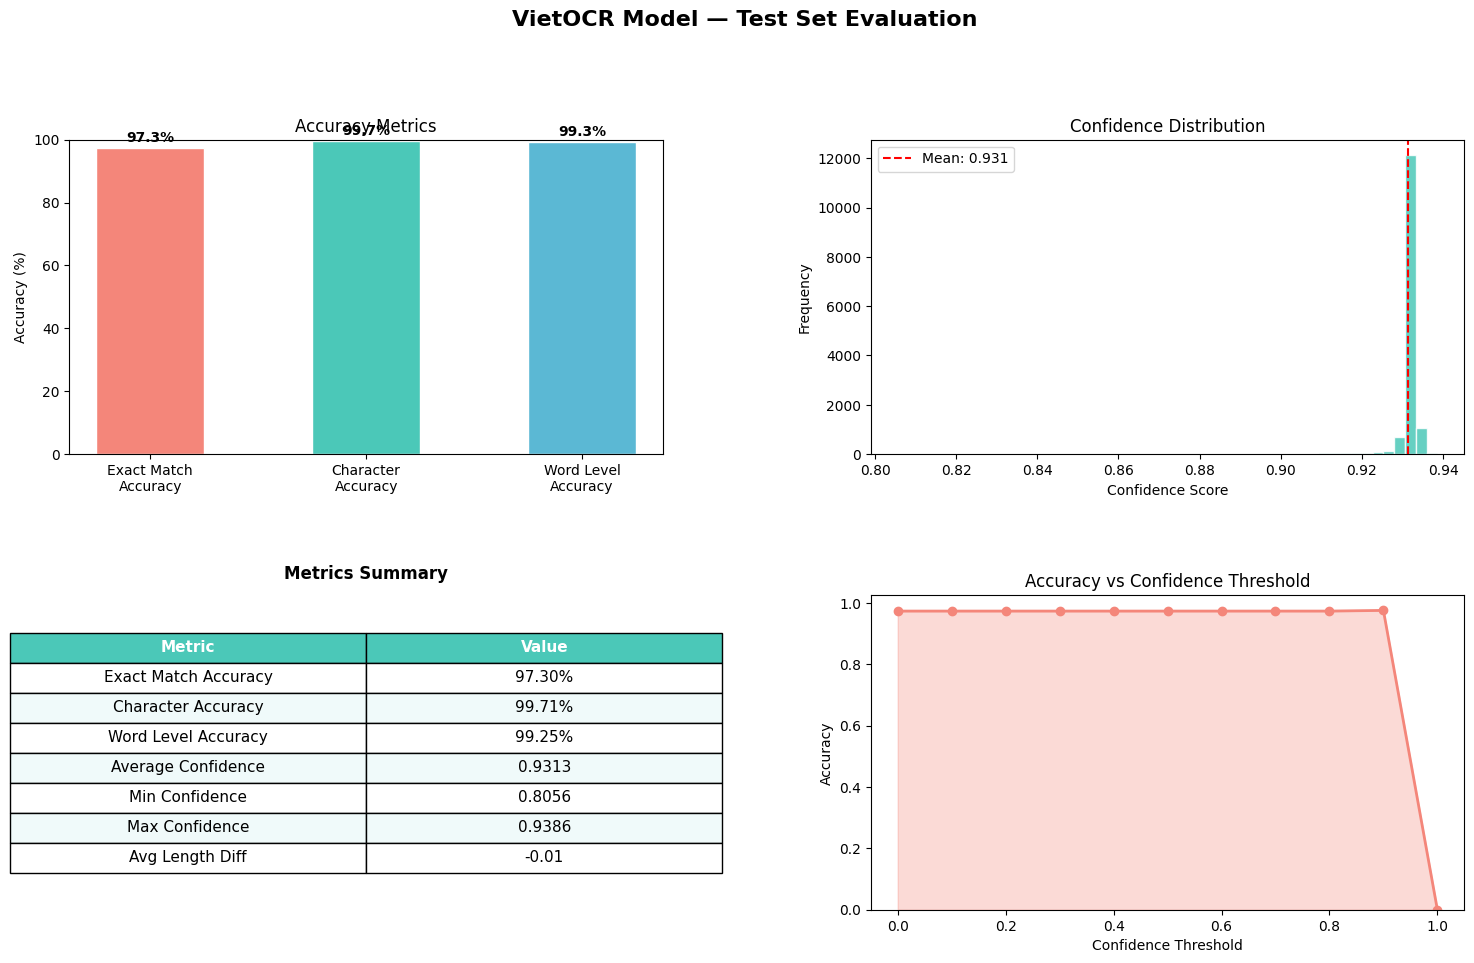

Đã lưu biểu đồ tại: /content/drive/MyDrive/vietocr_output_cccd/evaluation_charts.png


In [ ]:
# ============================================================
# EVALUATION + VISUALIZATION
# ============================================================
import os, editdistance
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm import tqdm
from vietocr.tool.predictor import Predictor
from vietocr.tool.config import Cfg

# --- Config ---
OUTPUT_DIR   = '/content/drive/MyDrive/vietocr_output_cccd'
WEIGHT_PATH  = f'{OUTPUT_DIR}/best_model.pth'
TEST_ANN     = f'{OUTPUT_DIR}/test_annotation.txt'
N_SAMPLES    = None   # None = toàn bộ, hoặc đặt số ví dụ 500 để test nhanh

# --- Load model ---
config = Cfg.load_config_from_name('vgg_transformer')
config['weights']                   = WEIGHT_PATH
config['device']                    = 'cuda'
config['predictor']['beamsearch']   = False
predictor = Predictor(config)

# --- Helper ---
def compute_wer(ref, hyp):
    ref_w, hyp_w = ref.strip().split(), hyp.strip().split()
    d = editdistance.eval(ref_w, hyp_w)
    return d / max(len(ref_w), 1)

# --- Load annotations ---
samples = []
with open(TEST_ANN, encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            parts = line.split('\t', 1)
            if len(parts) == 2:
                samples.append((parts[0].strip(), parts[1].strip()))

if N_SAMPLES:
    samples = samples[:N_SAMPLES]

print(f'Evaluating {len(samples)} samples...')

# --- Evaluation loop ---
correct     = 0
cer_total   = 0.0
wer_total   = 0.0
confidences = []
len_diffs   = []

for img_path, true_label in tqdm(samples, desc='Evaluating'):
    try:
        img  = Image.open(img_path).convert('RGB')
        pred, conf = predictor.predict(img, return_prob=True)

        if pred.strip() == true_label.strip():
            correct += 1

        cer_total  += editdistance.eval(true_label, pred) / max(len(true_label), 1)
        wer_total  += compute_wer(true_label, pred)
        confidences.append(conf)
        len_diffs.append(len(pred) - len(true_label))
    except Exception as e:
        pass

total               = len(samples)
exact_acc           = correct / total * 100
char_acc            = (1 - cer_total / total) * 100
word_acc            = (1 - wer_total / total) * 100
avg_conf            = np.mean(confidences)
confidences         = np.array(confidences)

print(f'\nExact Match Accuracy : {exact_acc:.2f}%')
print(f'Character Accuracy   : {char_acc:.2f}%')
print(f'Word Level Accuracy  : {word_acc:.2f}%')
print(f'Average Confidence   : {avg_conf:.4f}')

# ============================================================
# VISUALIZATION
# ============================================================
fig = plt.figure(figsize=(18, 10))
fig.suptitle('VietOCR Model — Test Set Evaluation', fontsize=16, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

TEAL = '#4BC8B8'
PINK = '#F4867A'

# --- 1. Accuracy bar chart ---
ax1     = fig.add_subplot(gs[0, 0])
metrics = ['Exact Match\nAccuracy', 'Character\nAccuracy', 'Word Level\nAccuracy']
values  = [exact_acc, char_acc, word_acc]
colors  = [PINK, TEAL, '#5BB8D4']
bars    = ax1.bar(metrics, values, color=colors, width=0.5, edgecolor='white')
ax1.set_ylim(0, 100)
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Accuracy Metrics')
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# --- 2. Confidence distribution ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(confidences, bins=50, color=TEAL, edgecolor='white', alpha=0.85)
ax2.axvline(avg_conf, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {avg_conf:.3f}')
ax2.set_xlabel('Confidence Score')
ax2.set_ylabel('Frequency')
ax2.set_title('Confidence Distribution')
ax2.legend()

# --- 3. Metrics summary table ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.axis('off')
table_data = [
    ['Exact Match Accuracy', f'{exact_acc:.2f}%'],
    ['Character Accuracy',   f'{char_acc:.2f}%'],
    ['Word Level Accuracy',  f'{word_acc:.2f}%'],
    ['Average Confidence',   f'{avg_conf:.4f}'],
    ['Min Confidence',       f'{confidences.min():.4f}'],
    ['Max Confidence',       f'{confidences.max():.4f}'],
    ['Avg Length Diff',      f'{np.mean(len_diffs):.2f}'],
]
tbl = ax3.table(cellText=table_data, colLabels=['Metric', 'Value'],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.8)
# Header style
for j in range(2):
    tbl[(0, j)].set_facecolor(TEAL)
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')
# Alternating row colors
for i in range(1, len(table_data)+1):
    for j in range(2):
        tbl[(i, j)].set_facecolor('#F0FAFA' if i % 2 == 0 else 'white')
ax3.set_title('Metrics Summary', fontweight='bold', pad=12)

# --- 4. Accuracy vs Confidence Threshold ---
ax4         = fig.add_subplot(gs[1, 1])
thresholds  = np.arange(0, 1.05, 0.1)
acc_at_thr  = []
with open(TEST_ANN, encoding='utf-8') as f:
    lines = [l.strip() for l in f if l.strip()]
labels_map = {}
for line in lines:
    parts = line.split('\t', 1)
    if len(parts) == 2:
        labels_map[parts[0].strip()] = parts[1].strip()

# recompute per-sample correctness + conf  (already in memory)
sample_results = []
for img_path, true_label in samples:
    try:
        img  = Image.open(img_path).convert('RGB')
        pred, conf = predictor.predict(img, return_prob=True)
        sample_results.append((pred.strip() == true_label.strip(), conf))
    except:
        pass

for thr in thresholds:
    filtered = [(ok, c) for ok, c in sample_results if c >= thr]
    if filtered:
        acc_at_thr.append(sum(ok for ok, _ in filtered) / len(filtered) * 100)
    else:
        acc_at_thr.append(0)

ax4.fill_between(thresholds, acc_at_thr, alpha=0.3, color=PINK)
ax4.plot(thresholds, acc_at_thr, 'o-', color=PINK, linewidth=2)
ax4.set_xlabel('Confidence Threshold')
ax4.set_ylabel('Accuracy')
ax4.set_title('Accuracy vs Confidence Threshold')
ax4.set_ylim(0, 1.05 * max(acc_at_thr) if acc_at_thr else 100)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/100:.1f}'))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/evaluation_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu biểu đồ tại:', f'{OUTPUT_DIR}/evaluation_charts.png')